In [1]:
import numpy as np
import bilby
import matplotlib.pyplot as plt


In [2]:
# ── 1. Generate fake "kilonova-like" lightcurve data ──────────────────────────
# Model: mag(t) = m0 + alpha * log10(t)   (simple power-law fading)
np.random.seed(42)

TRUE_M0    = 17.5   # magnitude at t=1 day
TRUE_ALPHA =  2.0   # fading rate

t_obs = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0])  # days
sigma = 0.15  # photometric uncertainty (mag)

mag_true  = TRUE_M0 + TRUE_ALPHA * np.log10(t_obs)
mag_obs   = mag_true + np.random.normal(0, sigma, len(t_obs))


In [3]:
# ── 2. Define the model ───────────────────────────────────────────────────────
def kilonova_model(t, m0, alpha):
    return m0 + alpha * np.log10(t)

# ── 3. Define a custom bilby Likelihood ───────────────────────────────────────
class KilonovaLikelihood(bilby.Likelihood):
    def __init__(self, t, mag_obs, sigma):
        # parameters dict tells bilby what to sample
        super().__init__(parameters={"m0": None, "alpha": None})
        self.t       = t
        self.mag_obs = mag_obs
        self.sigma   = sigma

    def log_likelihood(self):
        m0    = self.parameters["m0"]
        alpha = self.parameters["alpha"]

        mag_model = kilonova_model(self.t, m0, alpha)
        residuals = self.mag_obs - mag_model

        # Gaussian log-likelihood
        return -0.5 * np.sum(
            (residuals / self.sigma) ** 2 + np.log(2 * np.pi * self.sigma**2)
        )

/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:83: FutureWarning: <class '__main__.KilonovaLikelihood'> log_likelihood or log_likelihood_ratio method does not accept 'parameters' as an argument. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(


In [4]:
# ── 4. Define priors ──────────────────────────────────────────────────────────
priors = bilby.core.prior.PriorDict({
    "m0":    bilby.core.prior.Uniform(15.0, 20.0, name="m0",    latex_label=r"$m_0$"),
    "alpha": bilby.core.prior.Uniform(0.0,   5.0, name="alpha", latex_label=r"$\alpha$"),
})


In [5]:
# ── 5. Run the sampler ────────────────────────────────────────────────────────
likelihood = KilonovaLikelihood(t_obs, mag_obs, sigma)

result = bilby.run_sampler(
    likelihood   = likelihood,
    priors       = priors,
    sampler      = "dynesty",
    nlive        = 200,          # number of live points — increase for real runs
    outdir       = "outdir_demo",
    label        = "kilonova_demo",
    clean        = True,
)

/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:127: FutureWarning: Setting non-trivial parameters for <class '__main__.KilonovaLikelihood'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
17:55 bilby INFO    : Running for label 'kilonova_demo', output will be saved to 'outdir_demo'
17:55 bilby INFO    : Analysis priors:
17:55 bilby INFO    : m0=Uniform(minimum=15.0, maximum=20.0, name='m0', latex_label='$m_0$', unit=None, boundary=None)
17:55 bilby INFO    : alpha=Uniform(minimum=0.0, maximum=5.0, name='alpha', latex_label='$\\alpha$', unit=None, boundary=None)
17:55 bilby INFO    : Analysis likelihood class: <class '__main__.KilonovaLikelihood'>
17:55 bilby INFO    : Analysis likelihood noise evidence: nan
/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:64: DeprecationWarning: Using parameters as state fo

1it [00:00, ?it/s]

/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:64: DeprecationWarning: Using parameters as state for KilonovaLikelihood. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(
/home/jean/miniconda3/lib/python3.13/site-packages/bilby/core/likelihood.py:113: FutureWarning: Parameter attribute queried for <class '__main__.KilonovaLikelihood'>. This is deprecated behaviour  and will be removed in Bilby version 3. See https://bilby-dev.github.io/bilby/parameters for more details.
  warnings.warn(msg, FutureWarning)
17:55 bilby INFO    : Written checkpoint file outdir_demo/kilonova_demo_resume.pickle
17:56 bilby INFO    : Rejection sampling nested samples to obtain 503 posterior samples
17:56 bilby INFO    : Sampling time: 0:00:05.677089
17:56 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the

17:56 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
17:56 bilby INFO    : Summary of results:
nsamples: 503
ln_noise_evidence:    nan
ln_evidence:  0.076 +/-  0.192
ln_bayes_factor:    nan +/-  0.192



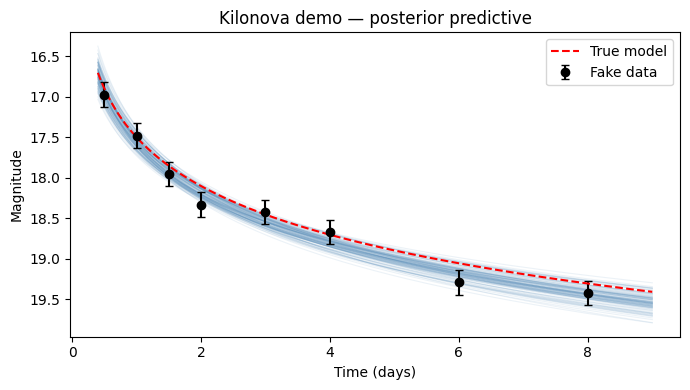


True values:  m0=17.5,  alpha=2.0
Recovered:    m0=17.558, alpha=2.064


In [6]:
# ── 6. Plot results ───────────────────────────────────────────────────────────
result.plot_corner()

# Plot data + posterior predictive
fig, ax = plt.subplots(figsize=(7, 4))
t_fine = np.linspace(0.4, 9, 200)

# Draw 100 random posterior samples
post = result.posterior.sample(100)
for _, row in post.iterrows():
    ax.plot(t_fine, kilonova_model(t_fine, row["m0"], row["alpha"]),
            color="steelblue", alpha=0.1, lw=0.8)

ax.errorbar(t_obs, mag_obs, yerr=sigma, fmt="ko", capsize=3, label="Fake data")
ax.plot(t_fine, kilonova_model(t_fine, TRUE_M0, TRUE_ALPHA),
        "r--", label="True model")
ax.invert_yaxis()   # magnitudes: brighter = smaller number
ax.set_xlabel("Time (days)")
ax.set_ylabel("Magnitude")
ax.set_title("Kilonova demo — posterior predictive")
ax.legend()
plt.tight_layout()
plt.savefig("kilonova_demo_fit.png", dpi=150)
plt.show()

print(f"\nTrue values:  m0={TRUE_M0},  alpha={TRUE_ALPHA}")
print(f"Recovered:    m0={result.posterior['m0'].median():.3f}, "
      f"alpha={result.posterior['alpha'].median():.3f}")